[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jibby2k1/SPS_Curriculum/blob/main/Intro_Math/Analysis/Real_Number_Systems.ipynb)


Content for and by IEEE Signal Processing Society. (Raul Valle)

# The Real Number Systems

### Visual setup & helpers
These utilities are used throughout to draw number-line and complex-plane figures.
*(Safe to re-run anytime.)*

In [16]:
# Setup & Visual Helpers
import math
import numpy as np
import matplotlib.pyplot as plt

# Use inline backend
# (In some environments, %matplotlib inline is implicit; keeping it explicit for clarity)
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

def _figure(title=None, xlabel=None, ylabel=None):
    fig, ax = plt.subplots(figsize=(6, 2.2))
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    return fig, ax

def plot_interval(a, b, closed_a=True, closed_b=True, title=None):
    """Draw one interval [a,b], (a,b], [a,b), or (a,b) on a number line."""
    if a > b:
        a, b = b, a
    fig, ax = _figure(title or f"Interval from {a} to {b}")
    # draw baseline
    ax.hlines(0, a - (b-a)*0.2, b + (b-a)*0.2)
    # interval segment
    ax.hlines(0, a, b, linewidth=4)
    # endpoints
    ax.plot([a], [0], 'o' if closed_a else 'o', fillstyle='full' if closed_a else 'none')
    ax.plot([b], [0], 'o' if closed_b else 'o', fillstyle='full' if closed_b else 'none')
    # ticks
    ax.set_yticks([])
    ax.set_xlim(a - (b-a)*0.3, b + (b-a)*0.3)
    ax.set_xticks([a, b])
    ax.grid(False)
    plt.show()

def plot_points_on_line(points, title=None):
    """points: sequence of floats. Marks them on a number line with a thin baseline."""
    if not points:
        return
    lo, hi = min(points), max(points)
    span = max(1.0, hi - lo)
    fig, ax = _figure(title or "Points on number line")
    ax.hlines(0, lo - 0.3*span, hi + 0.3*span)
    ax.plot(points, [0]*len(points), 'o', markersize=5)
    for x in points:
        ax.vlines(x, 0.05, 0.2, linewidth=1)
    ax.set_yticks([])
    ax.set_xlim(lo - 0.35*span, hi + 0.35*span)
    ax.grid(False)
    plt.show()

def visualize_sqrt2_approximations(k=6):
    """
    Show the absolute error |sqrt(2) - truncation| for decimal truncations of sqrt(2),
    plotted on a logarithmic y-scale.
    """
    r = math.sqrt(2)
    pts = [math.floor(r * 10**d) / 10**d for d in range(k + 1)]
    deltas = [abs(r - p) for p in pts]

    fig, ax = plt.subplots(figsize=(6, 3))
    xs = np.arange(0, k + 1)

    ax.plot(xs, deltas, "o-", label=r"$|\sqrt{2} - \text{truncation}|$")
    ax.set_yscale("log")
    ax.set_xlabel("Decimal places (k)")
    ax.set_ylabel("Absolute error (log scale)")
    ax.set_title(r"Convergence of decimal truncations to $\sqrt{2}$")
    ax.legend()
    ax.grid(True, which="both", ls="--", lw=0.5)
    plt.show()

def demonstrate_no_min_max_two(p=1.4):
    """
    Illustrate that there is no minimum or maximum rational near 2 in Q.
    Given p < 2, we compute q = (2p + 2)/(p + 2) satisfying p < q < 2.
    """
    q = (2 * p + 2.0) / (p + 2.0)

    fig, ax = _figure("No min/max in $\\mathbb{Q}$")
    lo, hi = min(q**2, p**2, 2.0), max(q**2, p**2, 2.0)
    span = max(1.0, hi - lo)

    # Base line (number line)
    ax.hlines(0, lo - 0.3 * span, hi + 0.3 * span, color="gray", linewidth=1.5)

    # Lines with distinct colors and labels for the legend
    ax.vlines(p**2, 0, 0.25, linestyles="--", colors="tab:blue", label=r"$p^2$")
    ax.vlines(q**2, 0, 0.25, linestyles="--", colors="tab:orange", label=r"$q^2$")
    ax.vlines(2.0, 0, 0.25, linestyles="--", colors="tab:red", label=r"$2$")

    # Styling
    ax.set_yticks([])
    ax.set_xlim(lo - 0.35 * span, hi + 0.35 * span)
    ax.legend(loc="upper center", ncol=3, frameon=False)
    plt.show()

def demonstrate_archimedean(x=0.3, y=2.7):
    """
    Visualize the Archimedean property: for x > 0, there exists n ∈ ℕ such that n*x > y.
    Shows multiples of x and highlights the smallest n satisfying n*x > y.
    """
    if x <= 0:
        raise ValueError("x must be positive")

    n = int(y // x) + 1
    xs = np.arange(0, n + 2)
    values = xs * x

    fig, ax = _figure("Archimedean property: multiples of x eventually exceed y")
    ax.set_facecolor("#fafafa")

    # Plot multiples of x
    ax.plot(values, np.zeros_like(values), "o-", color="tab:blue", label=r"$k \cdot x$")

    # Highlight the threshold y
    ax.axvline(y, color="tab:red", linestyle="--", linewidth=2, label=r"$y$")

    # Highlight n*x (the first that exceeds y)
    ax.axvline(values[n], color="tab:orange", linestyle="--", linewidth=2, label=fr"$n\cdot x={values[n]:.2f}$")
    ax.scatter(values[n], 0, s=100, color="tab:orange", zorder=5)
    ax.text(values[n], 0.05, f"n={n}", color="tab:orange", ha="center", fontsize=10, fontweight="bold")

    # Annotate region
    ax.hlines(0, 0, max(values)*1.1, color="gray", alpha=0.4)
    ax.set_xlim(-0.1 * max(values), 1.2 * max(values))
    ax.set_yticks([])
    ax.set_xlabel("Real line")
    ax.legend(loc="upper left", frameon=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.show()


---
### 🕐 Session 1 of 2 — *Why ℝ exists* (~35 min)
**Goal:** see the holes in $\mathbb{Q}$; define suprema/infima and the least-upper-bound property.
**Feeds into:** Session 2 (fields and the real field).

---

<details>
<summary>🎓 <b>Teacher notes — Session 1: Why ℝ exists</b></summary>

**Timing (~35 min).** 8 min the $\sqrt2$ irrationality proof · 12 min the no-max/no-min construction · 10 min sup/inf and the LUB property · 5 min the synthesis.

**This is the first workshop of the analysis track, so name what the whole track is for.** Every limit, integral, and transform the students will meet in [Signal Processing](../../Intro_DSP/README.md) presupposes that the numbers they are computing with actually exist. This session shows that the obvious number system — the one you can write down as fractions — **is not enough**, and identifies exactly the one property it lacks. Nothing here is decoration; the least-upper-bound property is the single axiom the rest of the track is built on.

**Open with the honest version of the motivating question.** The sequence $1, 1.4, 1.41, \dots$ "tends to $\sqrt2$" — but inside $\mathbb{Q}$ there is nothing for it to tend to. Do not resolve this. State plainly that we cannot even *define* the limit yet, that the definition arrives in [Sequences & Series](./Numerical_Sequences_and_Series.ipynb), and that this session's job is to build the number the sequence is aiming at. Leaving a debt open and naming when it will be paid is better teaching than a hand-wave.

**The irrationality proof is the room's first real proof by contradiction; slow down on the hinge.** The step students accept too quickly is "$a^2$ even $\Rightarrow$ $a$ even" — worth checking aloud, since it is the contrapositive of "odd × odd = odd". Then the punchline: "lowest terms" is the assumption that breaks. Some students find it unsatisfying that the contradiction is bookkeeping rather than arithmetic; the reframing that helps is *infinite descent* — you could keep halving forever, and no positive integer permits that.

**But be clear that irrationality alone is not the point of the session.** It shows one number is missing. The no-max/no-min construction shows something structurally worse: $\mathbb{Q}$ has a **gap** that no amount of patching fixes, because the sets on either side have no boundary element at all. Students often think the second proof is a harder restatement of the first. It is not, and saying so explicitly saves confusion.

**Give the recipe $q = p - \frac{p^2-2}{p+2}$ a meaning before verifying it algebraically.** It is Newton's method on $p^2 - 2$ in disguise — a mechanical nudge that takes any rational below $\sqrt2$ to a strictly larger rational still below $\sqrt2$. The algebra afterwards is just confirming that $q^2 - 2 = \frac{2(p^2-2)}{(p+2)^2}$ keeps the sign of $p^2 - 2$. Ask the room what would happen if you iterated it: they converge on $\sqrt2$ and never arrive, which is the picture the session wants.

**Then make the abstraction land.** $A$ has no greatest element, $B$ has no least, and every element of $A$ is below every element of $B$ — so there is a *cut* in $\mathbb{Q}$ with nothing sitting at it. Note that this is Dedekind's construction of $\mathbb{R}$: define a real number to **be** such a cut. We do not build it that way here, but naming the idea gives the axiom that follows a source rather than an air of arbitrariness.

**On sup and inf, insist on the two-part definition.** $\beta = \sup E$ requires (i) $\beta$ is an upper bound, and (ii) nothing smaller is. Students routinely check only (i). The second clause is where the word *least* lives, and it is the clause used in every proof in the next session — including the Archimedean property, where the whole argument is "$\alpha - x$ is not an upper bound."

**Close with the distinction that the entire session exists to make.** $\max$ must belong to the set; $\sup$ need not. $A = \{p \in \mathbb{Q} : p^2 < 2\}$ has no maximum, and in $\mathbb{Q}$ no supremum either — but in $\mathbb{R}$ its supremum is exactly $\sqrt2$. **The least-upper-bound property is precisely the promise that the ceiling a set strains toward is always a real number.** That sentence is the takeaway; everything in the next session is a consequence of it.
</details>

## Motivation

#### Visual: Approximating $\sqrt{2}$ with rationals

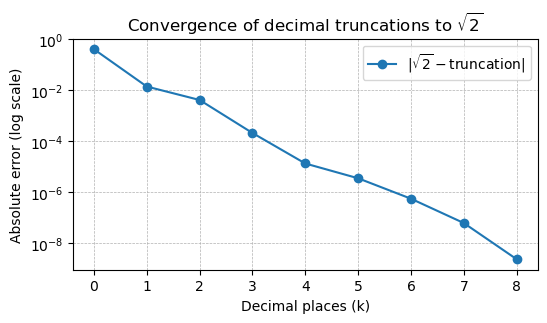

In [15]:
visualize_sqrt2_approximations(k=8)  # decimal truncations from below

**What just happened.** On the log axis the error falls in a near-straight line — roughly one decade per decimal place, exactly as truncating to $k$ digits should give an error below $10^{-k}$. By $k = 8$ the truncation $1.41421356$ sits within $2.4 \times 10^{-9}$ of $\sqrt2$. Every point plotted is a **rational number**, and they are closing on their target with no floor in sight.

**Which is precisely the problem this workshop exists to state.** Each of these approximations lives in $\mathbb{Q}$. The thing they are converging to does not. So inside $\mathbb{Q}$ we have a sequence whose terms get arbitrarily close to each other and which approaches **nothing at all** — there is no rational for it to reach. Nothing in the picture reveals this; the plot looks like healthy convergence right up to the point where you ask what it converges *to*.

**Notice what the log axis is and is not evidence for.** It shows the errors shrinking below any level we care to plot. It cannot show that a limit exists, because the limit is not a rational and the whole sequence is rational. This is the same lesson as every other numerical demo in the analysis track: computation exhibits behaviour, it does not establish existence. Existence is what the least-upper-bound property is for.

**The jaggedness is worth a glance too.** The line is not perfectly straight, because truncation approaches from below by whatever the next digits happen to be — at $k = 3$ the error is $2.1\times10^{-4}$, but at $k = 4$ it drops to $1.4\times10^{-5}$, a factor of 15 rather than 10. The bound $10^{-k}$ holds; the actual error wanders beneath it according to the digits of $\sqrt2$.

**And this frames the debt the analysis track is here to pay.** We cannot yet *define* what "tends to $\sqrt2$" means — the $\varepsilon$–$N$ definition arrives in [Sequences & Series](./Numerical_Sequences_and_Series.ipynb), and the statement that such sequences always have limits in $\mathbb{R}$ is the completeness theorem there. This session builds the number they are aiming at; that session explains what aiming means.

The rationals are inadequate for many reasons, for example $p^2 = 2$ does not exist in the rationals, but we can "approximate" irrationals using the rationals.

For example, the sequence: $(p_n) = \{1, 1.4, 1.41, ... \}$ "tends to" $\sqrt{2}$ using countably many values, but it is not clear what that means (in terms of the rational numbers, since it is irrational).

### Proof: $\sqrt{2} \notin \mathbb{Q}$

💡 **Intuition.** We argue by contradiction with a *parity* trick: if $\sqrt{2}$ were a fraction in lowest terms, squaring forces the numerator to be even, which then forces the denominator to be even too — but a fraction in lowest terms can't have *both* even. The fraction "collapses under its own weight.

Consider $p \in \mathbb{Q} : p^2 = 2$, then $p = \frac{a}{b}$ expressed in "least terms", where $a, b \in \mathbb{N}$ cannot be simplified further.

Then we can express $a^2 = 2 b^2$. Since $a^2$ is even, then each $a$ must also be even, so $\exists c \in \mathbb{N}: a=2c$.

Re-writing, $4c^2 = 2b^2$, or $2c^2 = b^2$. By similar arguments (with $a$), then $b$ must also be even, but this contradicts our fundamental assumption that $a$ and $b$ were in "least terms", therefore $p \notin \mathbb{Q} : p^2 = 2$. 

This proof alone shows that the rationals are missing some values that we hope exist (in $\mathbb{R}$).

Let us further analyze the problem, we will show that for $A := p \in \mathbb{Q} : p^2 < 2$ and $B := p \in \mathbb{Q} : p^2 > 2$, that $A$ has no greatest element, and $B$ has no least element.

### Proof: $\max ((-\infty, 2) \cap \mathbb{Q}) = \emptyset$ and $\min ((2, \infty) \cap \mathbb{Q}) = \emptyset$

#### Visual: There is no maximum rational below 2
Pick any rational $p$; there exists a $q$ such that $p^2 < q^2 <2$ or $2 < q^2 < p^2$ .

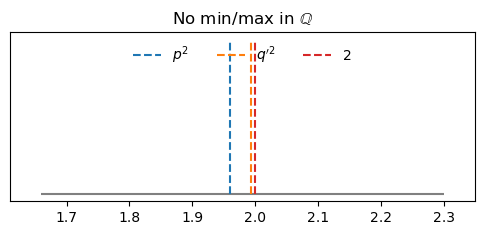

In [11]:
demonstrate_no_min_max_two(p=1.4)

**What just happened.** Three marks on the line, in this order: $p^2 = 1.96$, then $q^2 = 1.99307$, then $2$. Feeding in $p = 1.4$, the recipe returned $q = \frac{2(1.4)+2}{1.4+2} = \frac{4.8}{3.4} = 1.41176\ldots$ — a **rational** number, strictly larger than $p$, whose square is still strictly below 2.

**So $p$ was not the largest element of $A$. And neither is $q$.** Feed $q$ back in and the recipe produces something larger again, still rational, still below $\sqrt2$. It never terminates and it never overshoots. The set $A = \{p \in \mathbb{Q} : p^2 < 2\}$ therefore has **no maximum** — not "a maximum that is hard to find", but no maximum, provably, because any candidate is refuted by one application of a formula.

**Watch where the sign does the work.** The algebra gives $q^2 - 2 = \frac{2(p^2 - 2)}{(p+2)^2}$, and the denominator is positive, so $q^2 - 2$ carries **the same sign as $p^2 - 2$**. Below stays below; above stays above. That single identity proves both halves at once: $A$ has no maximum and $B = \{p : p^2 > 2\}$ has no minimum, since the same map run from above descends without reaching 2.

**This is a strictly stronger statement than "$\sqrt2$ is irrational", which is why it gets its own proof.** Irrationality says one number is missing from $\mathbb{Q}$. This says $\mathbb{Q}$ has a **structural gap**: two sets, every element of $A$ below every element of $B$, together exhausting the rationals, and *nothing sitting at the boundary*. There is no rational you could insert to repair it, because there is no place to insert it — neither side has an edge.

**And notice this happens despite $\mathbb{Q}$ being dense in itself.** Between any two rationals lies $\frac{a+b}{2}$, another rational; there are no "adjacent" rationals anywhere. Density and completeness are independent properties, and $\mathbb{Q}$ has the first without the second. The number line drawn here looks solid at every resolution you can plot and is riddled with holes.

**Which is exactly the shape of the axiom coming next.** Dedekind's idea is to *define* a real number to be a cut like this one — the gap itself becomes the number. We take the axiomatic route instead and simply require the least-upper-bound property, but the motivation is the same: whatever $\mathbb{R}$ is, it must be the thing in which $\sup A$ exists. That supremum will be $\sqrt2$.

💡 **Intuition.** The proof looks algebraic, but the idea is simple: hand me *any* rational whose square is below 2, and I have a mechanical recipe ($q = p - \frac{p^2-2}{p+2}$) that nudges it a bit closer to $\sqrt{2}$ while keeping it rational and still below. So no rational can be "the last one" — the set keeps straining upward toward a ceiling that isn't in $\mathbb{Q}$.

#### Prove A has no maximum.

Let $A := p \in \mathbb{Q} : p^2 < 2$.

Choose $p \in A \cap (0, +\infty)$ (to avoid trivial arguments).

Then we can define $q := p - \frac{p^2 - 2}{p+2} = \frac{2p + 2}{p + 2}$

Furthermore, $q^2 - 2 = 4 \frac{(p + 1)^2}{(p + 2)^2} - 2 = \frac{4p^2 + 8p + 4}{(p + 2)^2} - \frac{2p^2 + 8p + 8}{(p + 2)^2} = \frac{2(p^2-2)}{(p+2)^2}$

By construction, $q > p$ because $p^2 -2 < 0$, and $q^2 < 2$ because $q^2 - 2 < 0$ (dependent on $p^2 - 2$ again).

#### Prove B has no minimum.

Same as with $A$ using same construction.

Overall, the purpose of this discussion was to show hat the rationals have gaps despite rationals living between each other: $\forall a,b \in \mathbb{Q} (\text{without loss of generality}) : a \le \frac{a+b}{2} \le b$ 

### General Notation

$x \in A \text{ implies that x is an element of the set A, else } x\notin A$

$A = \emptyset \text{ implies that the set A has no elements, called the empty set.}$

$A \subset B \text{ implies that } \forall a: a \in A, a \in B, A \neq B \text{ called the proper subset}$

$A \subseteq B \text{ implies that } \forall a: a \in A, a \in B, \text{ with possible equality}$

## Ordered Sets

💡 **Intuition.** The *supremum* is "the number a set is straining to reach": the least of all ceilings. The subtle point — and the whole reason $\mathbb{R}$ exists — is that the supremum need **not** belong to the set, and for sets of rationals it may not even belong to $\mathbb{Q}$. The least-upper-bound property is the promise that in $\mathbb{R}$, the ceiling you're straining toward is always an actual number.

Let $S$ be a set, an order on $S$ is a relation denoted by $<$ such that:

i) For $x, y \in S: x=y, x<y, \text{ or (exclusive) } x>y$

ii) For $x, y, z \in S: x<y, y<z \text{ then } x < z \text{ (without loss of generality)}$

An ordered set is a set with an order ( i.e. $ \mathbb{Q} $ )

A set $S$ is bounded above (upper-bound) if $\exists \beta: \forall s \in S, s \le \beta$

A set $S$ is bounded below (lower-bound) if $\exists \alpha: \forall s \in S, s \ge \alpha$

The supremum $\beta$ of an ordered set $E\subset S$ is the least upper-bound. Formally, $\forall e \in E: e \le \beta$ and $\forall \gamma < \beta, \exists e \in E : \gamma < e$

The infimum $\alpha$ of an ordered set $E\subset S$ is the greatest lower-bound. Formally, $\forall e \in E: e \ge \alpha$ and $\forall \gamma > \alpha, \exists e \in E : \gamma > e$

<details>
<summary>🎓 <b>Teacher notes — Session 2: Fields & the Real Field</b></summary>

**Timing (~35 min).** 5 min fields and what we are skipping · 10 min the Archimedean property · 10 min density of $\mathbb{Q}$ · 5 min density of the irrationals · 5 min synthesis.

**Be upfront about what this session assumes rather than proves.** We *postulate* that an ordered field with the least-upper-bound property exists and contains $\mathbb{Q}$. Constructing it — by Dedekind cuts or by equivalence classes of Cauchy sequences — is a real piece of work and is deliberately out of scope. Say so plainly and say why: the interesting content for this audience is what the LUB property *buys*, not the carpentry of building a model that has it. Students who want the construction should be pointed at Rudin ch. 1 appendix.

**Frame the session's real question: what does one axiom actually give you?** Everything after this point — Archimedes, density of $\mathbb{Q}$, density of the irrationals — is a consequence of the LUB property alone. That is the lesson worth carrying: a single well-chosen axiom generates the entire fine structure of the number line.

**The Archimedean property looks obvious, so make the room feel why it needs proof.** "Take small enough steps often enough and you pass anything" is intuitively unarguable — and it is *false* in some ordered fields. Non-Archimedean fields exist, with infinitesimals smaller than every $1/n$; the hyperreals are the standard example. So this is not a triviality, it is a theorem, and the LUB property is exactly what rules out infinitesimals. That framing turns a boring result into an interesting one.

**Then walk the proof by contradiction slowly, because it is the LUB property's first real use.** Assume $nx \le y$ for all $n$. Then $A = \{nx\}$ is bounded above, so $\alpha = \sup A$ exists — *this is the only place the axiom enters*. Since $x > 0$, $\alpha - x < \alpha$, so $\alpha - x$ is **not** an upper bound (this is clause (ii) of the sup definition, the one students skip), giving some $mx > \alpha - x$, hence $(m+1)x > \alpha$. But $(m+1)x \in A$, contradicting that $\alpha$ bounds $A$. Point at the moment clause (ii) is used; it is the entire argument.

**Density of $\mathbb{Q}$ is best taught as a ruler argument before the inequalities.** Given $x < y$, choose a ruler fine enough that its tick spacing $1/n$ is smaller than the gap $y - x$ — Archimedes supplies such an $n$. A gap wider than the spacing must contain a tick. The formal proof is that idea plus care in picking the right $m$, and the chain $nx < m \le 1 + nx < ny$ is worth writing on the board in full so the room sees where each inequality came from.

**Note the dependency, since it justifies the ordering of the session.** Density of $\mathbb{Q}$ *uses* the Archimedean property, which *uses* the LUB property. Three results, one axiom, each one leaning on the previous. Students who see the chain understand why the material is sequenced this way rather than by apparent difficulty.

**The irrational density proof is short and rewards one extra remark.** Shift the rational $q$ by $\sqrt2/n$ — small enough to stay in the gap, irrational enough to leave $\mathbb{Q}$. The remark: rational + irrational is *always* irrational, since otherwise subtracting the rational would make the irrational rational. So both $\mathbb{Q}$ and its complement are dense: **every interval, however tiny, contains infinitely many of each.** They are perfectly interleaved.

**Close by contrasting that interleaving with what comes later, because it is the seed of the next two workshops.** $\mathbb{Q}$ and the irrationals are both dense, yet $\mathbb{Q}$ is countable and the irrationals are not ([Basic Topology](./Basic_Topology.ipynb)), and $\mathbb{Q}$ has measure zero while the irrationals have full measure ([Measure Theory](./Measure_Theory.ipynb)). Same interleaving on the line; three different verdicts on which set is "most" of $\mathbb{R}$. Density, cardinality, and measure are independent notions of size, and the analysis track spends the next three workshops separating them.
</details>

### Proof: $\alpha, \beta \notin \mathbb{Q}$

Recall previously that we proved that $\max (A = (-\infty, 2) \cap \mathbb{Q}) = \emptyset$ and $\min (B = (2, \infty) \cap \mathbb{Q}) = \emptyset$

There are 2 important details:

1) $\forall a \in A, b \in B: a < b$ (by construction).
2) $\max (A) = \emptyset$ and $\min (B) = \emptyset$

This shows that identifying $\beta = \sup{A}$ or $\alpha = \inf{B}$ is not possible. 

We propose $\mathbb{R}$ as the completion of $\mathbb{Q}$ which enables the identification of these elements.

---
### 🕐 Session 2 of 2 — *Fields & the Real Field* (~35 min)
**Goal:** build $\mathbb{R}$ axiomatically; prove the Archimedean property and the density theorems.
**Builds on:** Session 1 (ordered sets, sup/inf).

---

## Fields

A field is a set $F$ with the operations addition and multiplication.

Addition and Multiplication have well-known axioms (I won't cover here for brevity).

An ordered field $F$ is also an ordered set following the classical arithmetic intuitions.


## The Real Field

$ \exists \mathbb{R} $ which is an ordered field and has the least-upper-bound property. Moreover, $\mathbb{Q} \subset \mathbb{R}$. In consideration of time and effort, we propose this exist, but leave the proof out.

### Proof: $\exists n \in \mathbb{N}: \forall x>0,y \in \mathbb{R}, nx > y$ (Archimedean Property)

#### Visual: Archimedean property via multiples of $x>0$

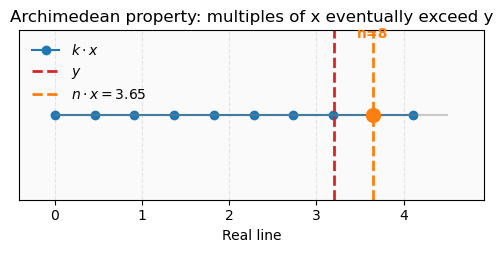

In [17]:
demonstrate_archimedean(x=0.456, y=3.2)

**What just happened.** Steps of size $x = 0.456$ march along the line, and the highlighted point is the first one past the target $y = 3.2$: at $n = 8$, $nx = 3.648 > 3.2$. Seven steps were not enough ($7 \times 0.456 = 3.192$, just short); the eighth clears it. Nothing subtle — and that is the point of the picture, because the theorem behind it is not obvious at all.

**The claim looks like arithmetic and is actually an axiom in disguise.** "Small steps, taken often enough, pass anything" fails in some ordered fields. A non-Archimedean field contains **infinitesimals** — elements $\epsilon > 0$ smaller than $1/n$ for every natural $n$ — and no multiple of such an $\epsilon$ ever reaches 1. The hyperreals of non-standard analysis are exactly that, and they are a perfectly consistent ordered field. So the property being demonstrated here is not a consequence of arithmetic; it is a consequence of **completeness**.

**Trace where the LUB property enters the proof, because that is the whole content.** Suppose the multiples never passed $y$. Then $\{nx\}$ is bounded above, so it has a supremum $\alpha$ — *this step, and only this step, needs the axiom*. Since $x > 0$, $\alpha - x$ is smaller than $\alpha$ and therefore not an upper bound, so some $mx$ exceeds it, so $(m+1)x > \alpha$ — but $(m+1)x$ is itself in the set. Contradiction.

**Note which half of the sup definition did the work.** Not "$\alpha$ is an upper bound", which students always check, but "**nothing smaller is an upper bound**" — clause (ii), the one that makes it *least*. If $\alpha$ were merely some upper bound the argument collapses immediately. Every proof in this session turns on that clause, and it is the usual place a first attempt goes wrong.

**So the Archimedean property is what rules out infinitesimals in $\mathbb{R}$, and the consequences run through everything downstream.** It is why $1/n \to 0$, why there is no "smallest positive real", and why the $\varepsilon$ in every $\varepsilon$–$N$ argument in [Sequences & Series](./Numerical_Sequences_and_Series.ipynb) can always be beaten by some $1/n$. It is also the engine of the density proof immediately below: to fit a rational into the gap $(x, y)$, first find a ruler with tick spacing $1/n < y - x$, which is Archimedes applied to $x = y - x$ and $y = 1$.

**One honest note about the figure.** It confirms the property for one $x$ and one $y$ by direct computation, which is all a plot can do. The theorem quantifies over *every* positive $x$ and *every* $y$, including $x$ smaller than any float you can represent — and it is precisely at that end of the range that the statement stops being obvious. The picture is an illustration; the contradiction argument is the evidence.

💡 **Intuition.** Take steps of any fixed size $x > 0$ — no matter how small — and you will eventually pass any target $y$. The proof turns this on its head: if you *never* passed $y$, your steps would have a least ceiling $\alpha$, but then $\alpha - x$ sits below some step, putting the *next* step above $\alpha$. Contradiction.

Let $A:= \{a_n = nx \}$

Suppose that $\forall a \in A, a \le y$, then $y$ is a UB of $A$.

In fact, since $\mathbb{R}$ has the LUB property, $\exists \alpha = \sup{A}$.

Since $x > 0, \alpha - x < \alpha$ and $\alpha-x$ is not UB. Therefore, $\exists m \in \mathbb{N} : \alpha - x < mx$.

But then, $\alpha < (m+1)x$ which is impossible since we assumed that $\alpha$ was the least upper-bound.

### Proof: $\exists p \in \mathbb{Q}: \forall x, y \in \mathbb{R}, x < p < y$ (wlog)

💡 **Intuition.** Between any two distinct reals there's a gap of width $y - x$. Chop the number line into a grid of $\frac{1}{n}$-steps with $n$ large enough that the grid spacing is finer than the gap — then some grid point $\frac{m}{n}$ *must* land inside. Density of $\mathbb{Q}$ is just "a fine enough ruler always has a tick in the gap.

Since $ x < y  : y - x > 0$. Then by the Archimedean Property, $\exists n \in \mathbb{N}: n(y - x) > 1 \leftrightarrow 1 + nx < ny$

Apply the property again to find $m_1, m_2 \in \mathbb{N}: m_1 > nx, m_2 > -nx$, then $-m_2 < nx < m_1$

Then, $\exists m \in \mathbb{N}: -m_2 \le m \le m_1, m-1 \le nx < m$

Combining the inequalites, $nx < m \le 1 + nx < ny$. Dividing by $n, x < \frac{m}{n} < y$

### Proof: $\exists p \notin \mathbb{Q}: \forall x,y \in \mathbb{R}, x < p < y$ (wlog)

💡 **Intuition.** To find an *irrational* in the gap, take the rational $q$ we just found and shift it by a tiny irrational amount $\frac{\sqrt{2}}{n}$: rational + irrational is irrational, and a small enough shift stays inside the gap.

Since $x < y: 0 < \frac{\sqrt{2}}{n} < y - x$. 

By our previous proof, $\exists q \in \mathbb{Q}: x < q < y - \frac{\sqrt{2}}{n}$.

Then, $x < q < q + \frac{\sqrt{2}}{{n}} < y$, with $t = q + \frac{\sqrt{2}}{{n}}, t \notin \mathbb{Q}$

---
## Where next

- [Basic Topology](./Basic_Topology.ipynb) — open/closed sets, compactness: the structure of $\mathbb{R}$ we just built.
- [Numerical Sequences and Series](./README.md#3-numerical-sequences-and-series-available) — what "tends to $\sqrt{2}$" *actually means*, answering this workshop's opening question.
- The completeness of $\mathbb{R}$ is what makes limits, integrals, and transforms in [Signal Processing](../../Intro_DSP/README.md) well-defined.